In [ ]:
# Imports, Device Setup, Paths

import os
import glob
import re
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# My folders. Chnage the paths if you are trying to reproduce the pipeline.
train_folder = r"C:\Users\RMN9SH\Desktop\NavierStokes (2)\train"
test_folder  = r"C:\Users\RMN9SH\Desktop\NavierStokes (2)\test"

# We'll use Re ≤ 1000 as training-range flows
MAX_RE_TRAIN = 1000


Using device: cpu


In [ ]:
# Loader functions for train + test

def load_ns_folder_max_re(folder_path, max_re=None):
    """
    Load all .npy files in folder_path with Reynolds number <= max_re.
    Assumes filenames: 'Re_350.npy', etc. Each file: (T, 4, H, W).
    Drops channel 1 (vertical velocity), keeps 0, 2, 3 (3 channels).
    Returns: numpy array (N, 3, H, W)
    """
    all_arrays = []
    npy_files = sorted(glob.glob(os.path.join(folder_path, "Re_*.npy")))
    print(f"[TRAIN LOADER] Found {len(npy_files)} files in {folder_path}")

    selected_files = []
    for fpath in npy_files:
        fname = os.path.basename(fpath)
        m = re.match(r"Re_(\d+)\.npy", fname)
        if not m:
            continue
        re_val = int(m.group(1))
        if max_re is not None and re_val > max_re:
            continue
        selected_files.append((re_val, fpath))

    if not selected_files:
        raise RuntimeError(f"No files selected in {folder_path} with max_re={max_re}")

    print("[TRAIN LOADER] Using files:")
    for re_val, fpath in selected_files:
        print(f"  Re={re_val:<5} -> {os.path.basename(fpath)}")

    for re_val, fpath in selected_files:
        data = np.load(fpath)  # (T, 4, H, W)
        if data.ndim != 4 or data.shape[1] != 4:
            raise ValueError(f"Unexpected shape in {fpath}: {data.shape}")
        # drop channel 1, keep 0, 2, 3
        data_3ch = np.stack([data[:, 0], data[:, 2], data[:, 3]], axis=1)  # (T, 3, H, W)
        all_arrays.append(data_3ch)

    all_data = np.concatenate(all_arrays, axis=0)  # (N, 3, H, W)
    print("[TRAIN LOADER] Combined shape:", all_data.shape)
    return all_data


def load_ns_folder_test_split(folder_path):
    """
    Split test folder into:
    - test_normal: Re ≤ 1000  (in-distribution)
    - test_hard:   Re > 1000  (out-of-distribution)
    Drops channel 1.
    Returns: (test_normal, test_hard) as numpy arrays (test_hard may be None).
    """
    all_normal = []
    all_hard   = []

    npy_files = sorted(glob.glob(os.path.join(folder_path, "Re_*.npy")))
    print(f"[TEST LOADER] Found {len(npy_files)} files in {folder_path}")

    for fpath in npy_files:
        fname = os.path.basename(fpath)
        m = re.match(r"Re_(\d+)\.npy", fname)
        if not m:
            continue
        re_val = int(m.group(1))
        data = np.load(fpath)
        if data.ndim != 4 or data.shape[1] != 4:
            raise ValueError(f"Unexpected shape in {fpath}: {data.shape}")

        data_3ch = np.stack([data[:, 0], data[:, 2], data[:, 3]], axis=1)  # (T, 3, H, W)

        if re_val <= 1000:
            all_normal.append(data_3ch)
        else:
            all_hard.append(data_3ch)

    test_normal = np.concatenate(all_normal, axis=0)
    print("[TEST LOADER] test_normal shape:", test_normal.shape)

    if len(all_hard) > 0:
        test_hard = np.concatenate(all_hard, axis=0)
        print("[TEST LOADER] test_hard   shape:", test_hard.shape)
    else:
        test_hard = None
        print("[TEST LOADER] No high-Re test files found.")

    return test_normal, test_hard


In [ ]:
# Load training and testing arrays

train_data = load_ns_folder_max_re(train_folder, max_re=MAX_RE_TRAIN)
test_normal, test_hard = load_ns_folder_test_split(test_folder)

print("Train data shape:", train_data.shape)
print("Test normal shape:", test_normal.shape)
print("Test hard shape:", None if test_hard is None else test_hard.shape)


[TRAIN LOADER] Found 28 files in C:\Users\RMN9SH\Desktop\NavierStokes (2)\train
[TRAIN LOADER] Using files:
  Re=100   -> Re_100.npy
  Re=1000  -> Re_1000.npy
  Re=120   -> Re_120.npy
  Re=140   -> Re_140.npy
  Re=15    -> Re_15.npy
  Re=150   -> Re_150.npy
  Re=20    -> Re_20.npy
  Re=200   -> Re_200.npy
  Re=250   -> Re_250.npy
  Re=30    -> Re_30.npy
  Re=350   -> Re_350.npy
  Re=40    -> Re_40.npy
  Re=450   -> Re_450.npy
  Re=500   -> Re_500.npy
  Re=60    -> Re_60.npy
  Re=600   -> Re_600.npy
  Re=650   -> Re_650.npy
  Re=750   -> Re_750.npy
  Re=80    -> Re_80.npy
  Re=850   -> Re_850.npy
  Re=900   -> Re_900.npy
[TRAIN LOADER] Combined shape: (819, 3, 128, 256)
[TEST LOADER] Found 8 files in C:\Users\RMN9SH\Desktop\NavierStokes (2)\test
[TEST LOADER] test_normal shape: (234, 3, 128, 256)
[TEST LOADER] test_hard   shape: (78, 3, 128, 256)
Train data shape: (819, 3, 128, 256)
Test normal shape: (234, 3, 128, 256)
Test hard shape: (78, 3, 128, 256)


In [ ]:
# Per-channel normalization (using TRAIN stats)

def compute_channel_stats(x):
    """
    x: (N, C, H, W)
    returns: mean[C], std[C]
    """
    mean = x.mean(axis=(0, 2, 3))
    std  = x.std(axis=(0, 2, 3))
    return mean, std

train_mean, train_std = compute_channel_stats(train_data)
train_std_safe = np.where(train_std < 1e-8, 1.0, train_std)

print("Train mean:", train_mean)
print("Train std :", train_std_safe)

def normalize(x, mean, std):
    x_norm = (x - mean[None, :, None, None]) / std[None, :, None, None]
    x_norm = np.clip(x_norm, -3.0, 3.0)
    return x_norm

def denormalize(x_norm, mean, std):
    """
    x_norm: tensor (B, C, H, W)
    mean, std: numpy arrays (C,)
    """
    mean_t = torch.tensor(mean, dtype=torch.float32, device=x_norm.device)[None, :, None, None]
    std_t  = torch.tensor(std,  dtype=torch.float32, device=x_norm.device)[None, :, None, None]
    return x_norm * std_t + mean_t

train_data_norm  = normalize(train_data,     train_mean, train_std_safe)
test_normal_norm = normalize(test_normal,    train_mean, train_std_safe)
test_hard_norm   = normalize(test_hard,      train_mean, train_std_safe) if test_hard is not None else None

np.savez("ns_norm_stats.npz", mean=train_mean, std=train_std_safe)

print("Normalized train shape:", train_data_norm.shape)
print("Normalized test_normal shape:", test_normal_norm.shape)
print("Normalized test_hard shape:", None if test_hard_norm is None else test_hard_norm.shape)


Train mean: [2.12690524e+01 1.00171609e+00 5.52103907e-04]
Train std : [8.68381799e+02 4.51077284e-01 2.68592273e-01]
Normalized train shape: (819, 3, 128, 256)
Normalized test_normal shape: (234, 3, 128, 256)
Normalized test_hard shape: (78, 3, 128, 256)


In [ ]:
# Dataset and DataLoaders

class NSDataset(Dataset):
    def __init__(self, data_array):
        self.data = data_array.astype(np.float32)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx])  # (3, H, W)

full_train_dataset     = NSDataset(train_data_norm)
test_normal_dataset    = NSDataset(test_normal_norm)
test_hard_dataset      = NSDataset(test_hard_norm) if test_hard_norm is not None else None

# Train / Val split (10% val)
val_ratio = 0.1
val_size  = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

dae_batch_size = 4  # small for CPU

dae_train_loader = DataLoader(train_dataset,      batch_size=dae_batch_size, shuffle=True)
dae_val_loader   = DataLoader(val_dataset,        batch_size=dae_batch_size, shuffle=False)
dae_test_normal_loader = DataLoader(test_normal_dataset, batch_size=dae_batch_size, shuffle=False)
dae_test_hard_loader   = (
    DataLoader(test_hard_dataset, batch_size=dae_batch_size, shuffle=False)
    if test_hard_dataset is not None else None
)

print("Train/Val/Test sizes:",
      len(train_dataset), len(val_dataset), len(test_normal_dataset),
      "(hard:", len(test_hard_dataset) if test_hard_dataset is not None else 0, ")")


Train/Val/Test sizes: 738 81 234 (hard: 78 )


In [ ]:
# Latent Autoencoder (LatentAE) with z_channels = 16

class LatentAE(nn.Module):
    def __init__(self, in_channels=3, z_channels=16, base_channels=32):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),
        )  # (B, 32, 128, 256)

        self.enc2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(True),
        )  # (B, 64, 64, 128)

        self.enc3 = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_channels*4),
            nn.ReLU(True),
        )  # (B, 128, 32, 64)

        self.enc4 = nn.Sequential(
            nn.Conv2d(base_channels*4, z_channels, 3, stride=2, padding=1),
            nn.BatchNorm2d(z_channels),
            nn.ReLU(True),
        )  # (B, z_channels, 16, 32)

        # Decoder
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(z_channels, base_channels*4, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels*4),
            nn.ReLU(True),
        )  # (B, 128, 32, 64)

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(base_channels*4, base_channels*2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(True),
        )  # (B, 64, 64, 128)

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(base_channels*2, base_channels, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),
        )  # (B, 32, 128, 256)

        self.final = nn.Conv2d(base_channels, in_channels, 3, padding=1)

    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        z = self.enc4(x)
        return z   # (B, z_channels, 16, 32)

    def decode(self, z):
        x = self.dec1(z)
        x = self.dec2(x)
        x = self.dec3(x)
        x = self.final(x)
        return x   # (B, 3, 128, 256)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

z_channels = 16
latent_ae = LatentAE(in_channels=3, z_channels=z_channels, base_channels=32).to(device)
latent_ae


LatentAE(
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (enc4): Sequential(
    (0): Conv2d(128, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (dec1): Sequential(
    (0): ConvTranspose2d(16, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): 

In [ ]:
# Train LatentAE with MSE loss

ae_criterion = nn.MSELoss()
ae_optimizer = optim.AdamW(latent_ae.parameters(), lr=1e-3, weight_decay=1e-4)

ae_num_epochs = 200
ae_train_history = []
ae_val_history   = []

for epoch in range(1, ae_num_epochs + 1):
    # train
    latent_ae.train()
    train_loss = 0.0
    for batch in dae_train_loader:
        batch = batch.to(device)
        ae_optimizer.zero_grad()
        recon, z = latent_ae(batch)
        loss = ae_criterion(recon, batch)
        loss.backward()
        ae_optimizer.step()
        train_loss += loss.item() * batch.size(0)
    train_loss /= len(dae_train_loader.dataset)

    # val
    latent_ae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in dae_val_loader:
            batch = batch.to(device)
            recon, z = latent_ae(batch)
            loss = ae_criterion(recon, batch)
            val_loss += loss.item() * batch.size(0)
    val_loss /= len(dae_val_loader.dataset)

    ae_train_history.append(train_loss)
    ae_val_history.append(val_loss)

    print(f"[LatentAE] Epoch {epoch:03d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")


[LatentAE] Epoch 001 | Train: 0.121403 | Val: 0.039358
[LatentAE] Epoch 002 | Train: 0.051903 | Val: 0.022921
[LatentAE] Epoch 003 | Train: 0.032882 | Val: 0.012057
[LatentAE] Epoch 004 | Train: 0.031618 | Val: 0.021105
[LatentAE] Epoch 005 | Train: 0.027125 | Val: 0.017024
[LatentAE] Epoch 006 | Train: 0.021672 | Val: 0.014461
[LatentAE] Epoch 007 | Train: 0.018140 | Val: 0.032049
[LatentAE] Epoch 008 | Train: 0.021674 | Val: 0.022860
[LatentAE] Epoch 009 | Train: 0.018280 | Val: 0.007749
[LatentAE] Epoch 010 | Train: 0.016999 | Val: 0.007496
[LatentAE] Epoch 011 | Train: 0.015822 | Val: 0.016063
[LatentAE] Epoch 012 | Train: 0.016087 | Val: 0.006361
[LatentAE] Epoch 013 | Train: 0.017660 | Val: 0.007834
[LatentAE] Epoch 014 | Train: 0.014980 | Val: 0.006398
[LatentAE] Epoch 015 | Train: 0.015891 | Val: 0.008709
[LatentAE] Epoch 016 | Train: 0.013578 | Val: 0.015142
[LatentAE] Epoch 017 | Train: 0.012456 | Val: 0.006985
[LatentAE] Epoch 018 | Train: 0.010714 | Val: 0.005613
[LatentAE]

In [ ]:
# Diffusion schedule + time embedding

num_diffusion_steps = 200  # T

def make_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

betas = make_beta_schedule(num_diffusion_steps).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)  # (T,)

def get_alphabar(t_idx):
    """
    t_idx: (B,) long
    returns: alpha_bar_t broadcast to (B,1,1,1)
    """
    return alpha_bars[t_idx].view(-1, 1, 1, 1)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.linear = nn.Linear(dim, dim)

    def forward(self, t):
        """
        t: (B,) long timesteps
        returns: (B, dim)
        """
        half_dim = self.dim // 2
        device_ = t.device
        emb = torch.arange(half_dim, device=device_).float()
        emb = emb / (half_dim - 1)
        emb = 10000 ** (-emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)   # (B, half_dim)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return self.linear(emb)


In [ ]:
# Tiny UNet for latent diffusion

class TinyUNet(nn.Module):
    def __init__(self, z_channels=16, base_channels=32, time_dim=64):
        super().__init__()

        self.time_mlp = TimeEmbedding(time_dim)
        self.time_to_c1 = nn.Linear(time_dim, base_channels)
        self.time_to_c2 = nn.Linear(time_dim, base_channels*2)

        # down
        self.conv1 = nn.Sequential(
            nn.Conv2d(z_channels, base_channels, 3, padding=1),
            nn.GroupNorm(4, base_channels),
            nn.ReLU(True),
        )  # (B, C, 16, 32)

        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, 3, stride=2, padding=1),
            nn.GroupNorm(8, base_channels*2),
            nn.ReLU(True),
        )  # (B, 2C, 8, 16)

        self.mid = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*2, 3, padding=1),
            nn.GroupNorm(8, base_channels*2),
            nn.ReLU(True),
        )

        # up
        self.up = nn.ConvTranspose2d(base_channels*2, base_channels, 4, stride=2, padding=1)
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels, 3, padding=1),
            nn.GroupNorm(4, base_channels),
            nn.ReLU(True),
        )

        self.final = nn.Conv2d(base_channels, z_channels, 3, padding=1)

    def forward(self, z_t, t):
        """
        z_t: (B, z_channels, 16, 32)
        t:   (B,) long
        """
        t_emb = self.time_mlp(t)  # (B, time_dim)

        h1 = self.conv1(z_t)
        t1 = self.time_to_c1(t_emb).view(-1, h1.shape[1], 1, 1)
        h1 = h1 + t1

        h2 = self.conv2(h1)
        t2 = self.time_to_c2(t_emb).view(-1, h2.shape[1], 1, 1)
        h2 = h2 + t2

        h_mid = self.mid(h2)

        h_up = self.up(h_mid)
        h_up = self.conv3(h_up)

        out = self.final(h_up)
        return out

diffusion_model = TinyUNet(z_channels=z_channels, base_channels=32, time_dim=64).to(device)
diffusion_model


TinyUNet(
  (time_mlp): TimeEmbedding(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (time_to_c1): Linear(in_features=64, out_features=32, bias=True)
  (time_to_c2): Linear(in_features=64, out_features=64, bias=True)
  (conv1): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
  )
  (mid): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
  )
  (up): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(4, 32, eps=1e-05, af

In [ ]:
# Train diffusion model on latent space

diffusion_criterion = nn.MSELoss()
diffusion_optimizer = optim.AdamW(diffusion_model.parameters(), lr=1e-4, weight_decay=1e-4)

diff_epochs = 200
diff_train_history = []
diff_val_history   = []

for epoch in range(1, diff_epochs + 1):
    diffusion_model.train()
    latent_ae.eval()

    train_loss = 0.0
    n_train = 0

    for batch in dae_train_loader:
        batch = batch.to(device)
        with torch.no_grad():
            _, z = latent_ae(batch)  # (B, z_channels, 16, 32)

        B = z.shape[0]
        t = torch.randint(0, num_diffusion_steps, (B,), device=device).long()
        eps = torch.randn_like(z)
        alpha_bar_t = get_alphabar(t)
        z_t = torch.sqrt(alpha_bar_t) * z + torch.sqrt(1.0 - alpha_bar_t) * eps

        eps_hat = diffusion_model(z_t, t)

        loss = diffusion_criterion(eps_hat, eps)
        diffusion_optimizer.zero_grad()
        loss.backward()
        diffusion_optimizer.step()

        train_loss += loss.item() * B
        n_train += B

    train_loss /= max(n_train, 1)

    # validation
    diffusion_model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for batch in dae_val_loader:
            batch = batch.to(device)
            _, z = latent_ae(batch)
            B = z.shape[0]
            t = torch.randint(0, num_diffusion_steps, (B,), device=device).long()
            eps = torch.randn_like(z)
            alpha_bar_t = get_alphabar(t)
            z_t = torch.sqrt(alpha_bar_t) * z + torch.sqrt(1.0 - alpha_bar_t) * eps

            eps_hat = diffusion_model(z_t, t)
            loss = diffusion_criterion(eps_hat, eps)
            val_loss += loss.item() * B
            n_val += B

    val_loss /= max(n_val, 1)

    diff_train_history.append(train_loss)
    diff_val_history.append(val_loss)

    print(f"[Diffusion] Epoch {epoch:03d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")


[Diffusion] Epoch 001 | Train: 1.008175 | Val: 0.991226
[Diffusion] Epoch 002 | Train: 0.976400 | Val: 0.945812
[Diffusion] Epoch 003 | Train: 0.910970 | Val: 0.873587
[Diffusion] Epoch 004 | Train: 0.862877 | Val: 0.830154
[Diffusion] Epoch 005 | Train: 0.824173 | Val: 0.804278
[Diffusion] Epoch 006 | Train: 0.799752 | Val: 0.784583
[Diffusion] Epoch 007 | Train: 0.773699 | Val: 0.752827
[Diffusion] Epoch 008 | Train: 0.747771 | Val: 0.743047
[Diffusion] Epoch 009 | Train: 0.728914 | Val: 0.727414
[Diffusion] Epoch 010 | Train: 0.716280 | Val: 0.702236
[Diffusion] Epoch 011 | Train: 0.699385 | Val: 0.697928
[Diffusion] Epoch 012 | Train: 0.683503 | Val: 0.670314
[Diffusion] Epoch 013 | Train: 0.672208 | Val: 0.665596
[Diffusion] Epoch 014 | Train: 0.664235 | Val: 0.663286
[Diffusion] Epoch 015 | Train: 0.650195 | Val: 0.648948
[Diffusion] Epoch 016 | Train: 0.637666 | Val: 0.646984
[Diffusion] Epoch 017 | Train: 0.632757 | Val: 0.625270
[Diffusion] Epoch 018 | Train: 0.627139 | Val: 0

In [ ]:
# DAE reconstruction, t_eval scan, and metrics

criterion = nn.MSELoss()  # for reconstruction MSE

def dae_reconstruct_batch(x, t_eval=None):
    """
    x: (B, 3, 128, 256) normalized input
    returns: reconstructed x_hat (B, 3, 128, 256)
    """
    latent_ae.eval()
    diffusion_model.eval()

    with torch.no_grad():
        _, z = latent_ae(x)  # (B, z_channels, 16, 32)

        B = z.shape[0]
        if t_eval is None:
            t = torch.full((B,), num_diffusion_steps // 2, device=device, dtype=torch.long)
        else:
            t = torch.full((B,), t_eval, device=device, dtype=torch.long)

        alpha_bar_t = get_alphabar(t)
        eps = torch.randn_like(z)
        z_t = torch.sqrt(alpha_bar_t) * z + torch.sqrt(1.0 - alpha_bar_t) * eps

        eps_hat = diffusion_model(z_t, t)
        # DDPM-style estimate of z0
        z0_hat = (z_t - torch.sqrt(1.0 - alpha_bar_t) * eps_hat) / torch.sqrt(alpha_bar_t)

        x_hat = latent_ae.decode(z0_hat)
        return x_hat

def eval_dae_mse_psnr(loader, name="set", t_eval=None):
    mse_sum = 0.0
    n = 0
    latent_ae.eval()
    diffusion_model.eval()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            x_hat = dae_reconstruct_batch(batch, t_eval=t_eval)
            mse = criterion(x_hat, batch).item()
            mse_sum += mse * batch.size(0)
            n += batch.size(0)

    avg_mse = mse_sum / max(n, 1)
    max_val = 6.0  # normalized ~[-3,3]
    psnr = 10 * np.log10((max_val ** 2) / avg_mse) if avg_mse > 0 else float("inf")

    print(f"[DAE {name}] t_eval={t_eval} | MSE={avg_mse:.6f}, PSNR={psnr:.2f} dB")
    return avg_mse, psnr

def scan_t_eval(loader, t_values):
    print("Scanning t_eval values on validation set...")
    results = []
    for t_eval in t_values:
        mse_sum = 0.0
        n = 0
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                x_hat = dae_reconstruct_batch(batch, t_eval=t_eval)
                mse = criterion(x_hat, batch).item()
                mse_sum += mse * batch.size(0)
                n += batch.size(0)
        avg_mse = mse_sum / max(n, 1)
        max_val = 6.0
        psnr = 10 * np.log10((max_val ** 2) / avg_mse) if avg_mse > 0 else float("inf")
        print(f"  t_eval={t_eval:3d} -> MSE={avg_mse:.6f}, PSNR={psnr:.2f} dB")
        results.append((t_eval, avg_mse, psnr))
    return results

# Scan a few candidate t_eval values on the validation set
t_candidates = [1, 5, 10, 20, 40, 80, 120, 150]
t_results = scan_t_eval(dae_val_loader, t_candidates)

# Pick the t_eval with the best (lowest) val MSE
best_t_eval, best_mse, best_psnr = min(t_results, key=lambda x: x[1])
print(f"\nBest t_eval on val: {best_t_eval} (MSE={best_mse:.6f}, PSNR={best_psnr:.2f} dB)")


Scanning t_eval values on validation set...
  t_eval=  1 -> MSE=0.002494, PSNR=41.59 dB
  t_eval=  5 -> MSE=0.002740, PSNR=41.19 dB
  t_eval= 10 -> MSE=0.003311, PSNR=40.36 dB
  t_eval= 20 -> MSE=0.005113, PSNR=38.48 dB
  t_eval= 40 -> MSE=0.011721, PSNR=34.87 dB
  t_eval= 80 -> MSE=0.043858, PSNR=29.14 dB
  t_eval=120 -> MSE=0.133049, PSNR=24.32 dB
  t_eval=150 -> MSE=0.275187, PSNR=21.17 dB

Best t_eval on val: 1 (MSE=0.002494, PSNR=41.59 dB)


In [ ]:
# Final DAE evaluation using best t_eval

print("\n==== Final DAE metrics with best t_eval ====")
dae_train_mse, dae_train_psnr = eval_dae_mse_psnr(dae_train_loader,       "Train",        t_eval=best_t_eval)
dae_val_mse,   dae_val_psnr   = eval_dae_mse_psnr(dae_val_loader,         "Val",          t_eval=best_t_eval)
dae_test_mse,  dae_test_psnr  = eval_dae_mse_psnr(dae_test_normal_loader, "Test (normal)", t_eval=best_t_eval)

if dae_test_hard_loader is not None:
    dae_hard_mse, dae_hard_psnr = eval_dae_mse_psnr(dae_test_hard_loader, "Test (hard)", t_eval=best_t_eval)
else:
    dae_hard_mse = dae_hard_psnr = None



==== Final DAE metrics with best t_eval ====
[DAE Train] t_eval=1 | MSE=0.002473, PSNR=41.63 dB
[DAE Val] t_eval=1 | MSE=0.002489, PSNR=41.60 dB
[DAE Test (normal)] t_eval=1 | MSE=0.004060, PSNR=39.48 dB
[DAE Test (hard)] t_eval=1 | MSE=0.053740, PSNR=28.26 dB


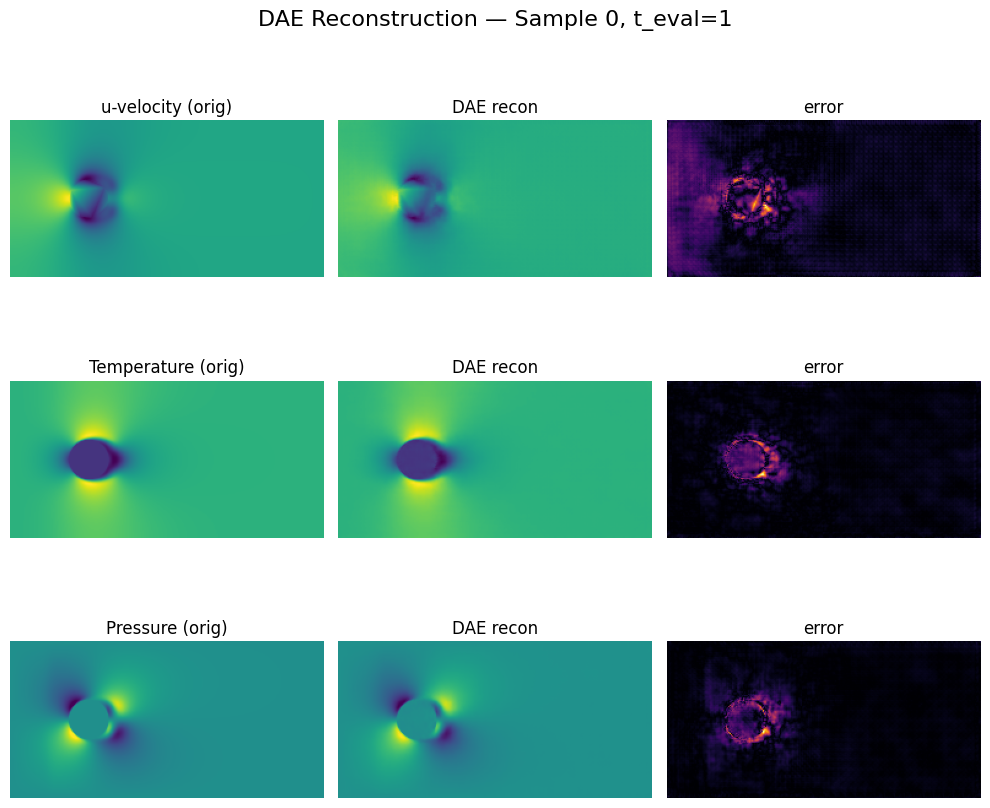

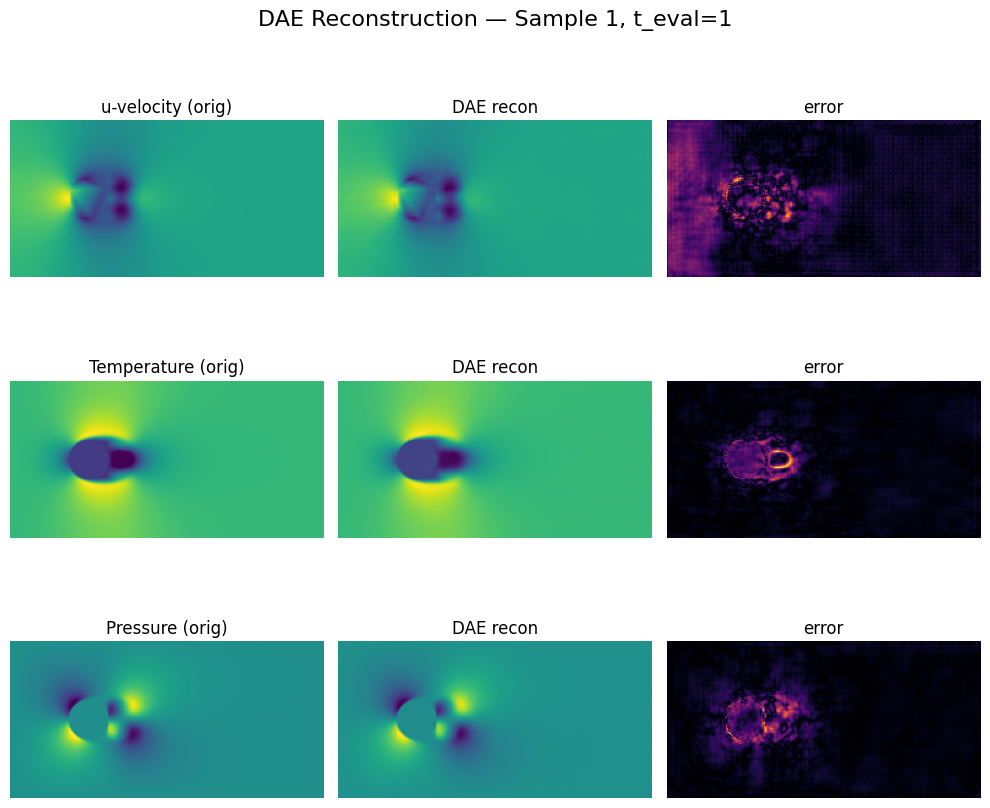

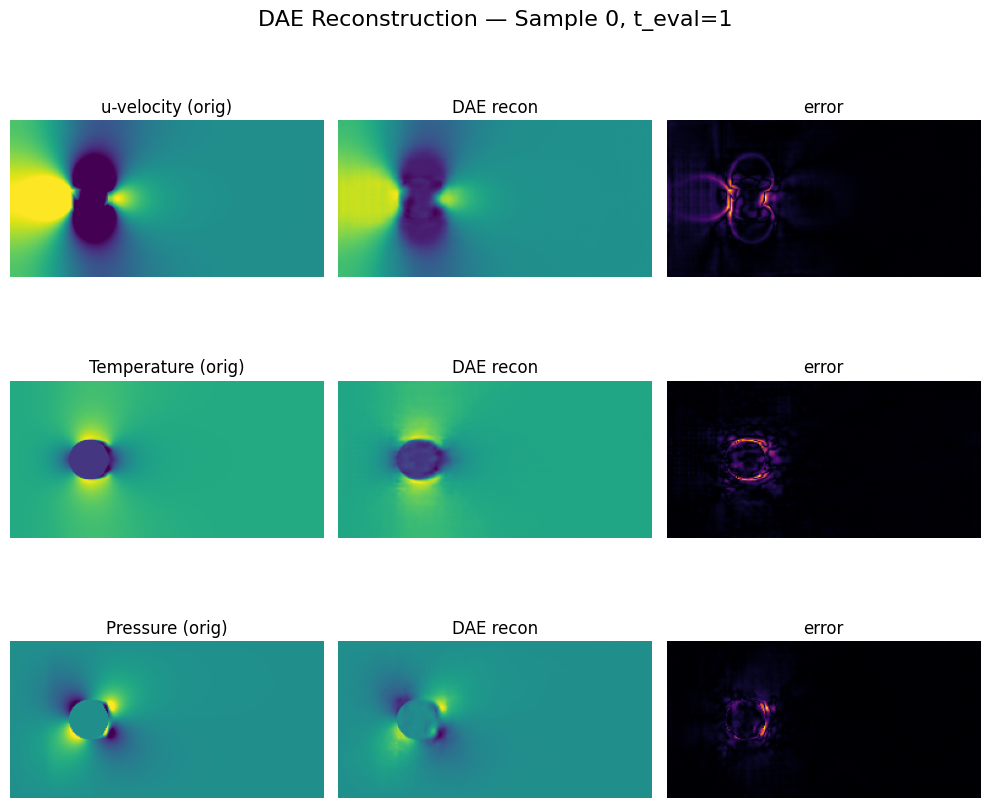

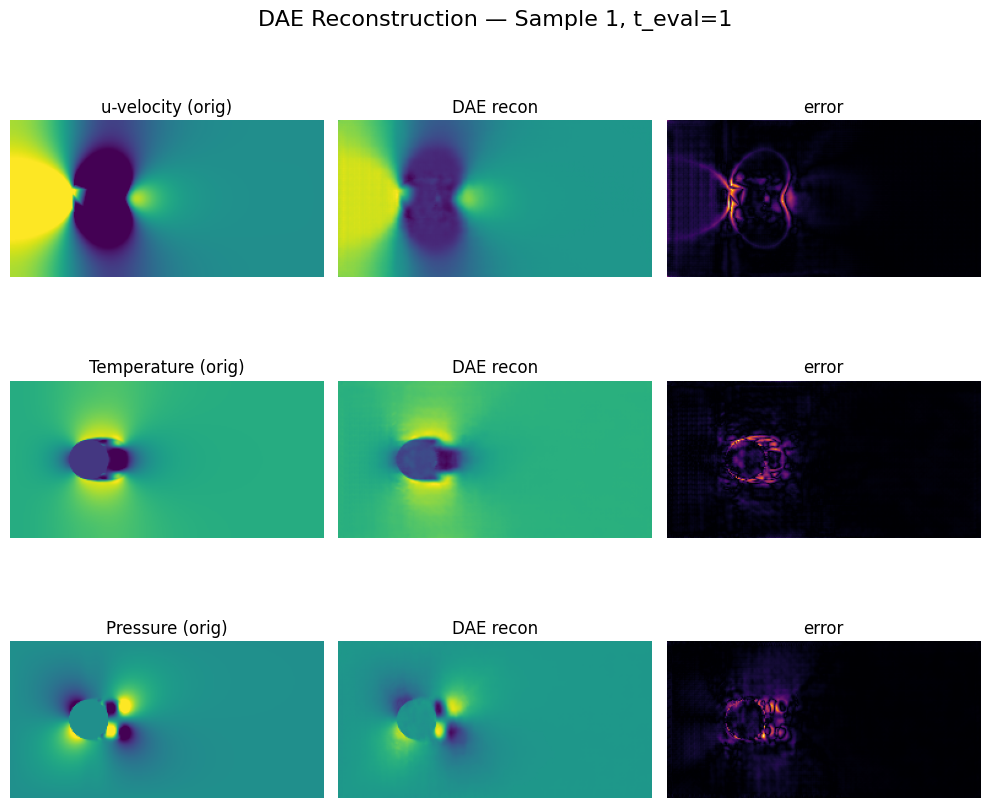

In [18]:
import matplotlib.pyplot as plt

def visualize_dae_reconstructions(
    loader,
    mean,
    std,
    num_samples=2,
    t_eval=None,
    cmap_flow="viridis",
    cmap_err="inferno",
):
    """
    Visualize DAE reconstructions on a batch from loader.
    """
    latent_ae.eval()
    diffusion_model.eval()

    batch = next(iter(loader))  # (B, 3, H, W)
    batch = batch.to(device)

    with torch.no_grad():
        x_hat = dae_reconstruct_batch(batch, t_eval=t_eval)

    orig_dn  = denormalize(batch,  mean, std).cpu().numpy()
    recon_dn = denormalize(x_hat,  mean, std).cpu().numpy()

    channel_titles = ["u-velocity", "Temperature", "Pressure"]
    n_show = min(num_samples, batch.shape[0])

    for i in range(n_show):
        fig, axs = plt.subplots(3, 3, figsize=(10, 9))
        fig.suptitle(f"DAE Reconstruction — Sample {i}, t_eval={t_eval}", fontsize=16)

        for c in range(3):
            orig_img  = orig_dn[i, c]
            recon_img = recon_dn[i, c]
            err_img   = np.abs(orig_img - recon_img)

            axs[c, 0].imshow(orig_img, cmap=cmap_flow)
            axs[c, 0].set_title(f"{channel_titles[c]} (orig)")
            axs[c, 0].axis("off")

            axs[c, 1].imshow(recon_img, cmap=cmap_flow)
            axs[c, 1].set_title("DAE recon")
            axs[c, 1].axis("off")

            axs[c, 2].imshow(err_img, cmap=cmap_err)
            axs[c, 2].set_title("error")
            axs[c, 2].axis("off")

        plt.tight_layout()
        plt.show()

# Example: visualize on normal & hard sets with best t_eval
visualize_dae_reconstructions(
    loader=dae_test_normal_loader,
    mean=train_mean,
    std=train_std_safe,
    num_samples=2,
    t_eval=best_t_eval,
)

if dae_test_hard_loader is not None:
    visualize_dae_reconstructions(
        loader=dae_test_hard_loader,
        mean=train_mean,
        std=train_std_safe,
        num_samples=2,
        t_eval=best_t_eval,
    )


In [19]:
import os
import re
import glob
import numpy as np
import torch
import imageio.v2 as imageio
import matplotlib.cm as cm

video_output_dir_dae = r"C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE"
os.makedirs(video_output_dir_dae, exist_ok=True)
print("DAE video output folder:", video_output_dir_dae)


DAE video output folder: C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE


In [20]:
def scalar_to_rgb(field, vmin=None, vmax=None, cmap_name="viridis"):
    """
    field: 2D numpy array (H, W)
    returns: (H, W, 3) uint8
    """
    if vmin is None:
        vmin = np.nanmin(field)
    if vmax is None:
        vmax = np.nanmax(field)
    if vmax <= vmin:
        vmax = vmin + 1e-6

    normed = (field - vmin) / (vmax - vmin)
    normed = np.clip(normed, 0.0, 1.0)

    cmap = cm.get_cmap(cmap_name)
    rgba = cmap(normed)  # (H, W, 4)
    rgb = (rgba[..., :3] * 255).astype(np.uint8)
    return rgb


In [21]:
def load_test_file_normalized(folder, re_value, mean, std):
    """
    Loads a single Re_XXXX.npy from test folder, drops channel 1,
    keeps channels 0,2,3 => (T, 3, H, W), normalizes with train stats,
    returns torch tensor on correct device.
    """
    fname = f"Re_{re_value}.npy"
    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"No file found for Re={re_value} at {fpath}")

    data = np.load(fpath)  # (T, 4, H, W)
    if data.ndim != 4 or data.shape[1] != 4:
        raise ValueError(f"Unexpected shape for {fpath}: {data.shape}")

    # Drop v (index 1), keep u, T, p
    data_3ch = np.stack([data[:, 0], data[:, 2], data[:, 3]], axis=1)  # (T, 3, H, W)

    # Reuse your normalize() defined earlier (per-channel using train_mean/std)
    data_norm = normalize(data_3ch, mean, std).astype(np.float32)
    tensor = torch.from_numpy(data_norm).to(device)  # (T, 3, H, W)
    return tensor


In [22]:
def get_re_values_in_folder(folder):
    """
    Returns sorted list of integer Re values from Re_*.npy files in folder.
    """
    npy_files = glob.glob(os.path.join(folder, "Re_*.npy"))
    re_vals = []
    for fpath in npy_files:
        fname = os.path.basename(fpath)
        m = re.match(r"Re_(\d+)\.npy", fname)
        if m:
            re_vals.append(int(m.group(1)))
    re_vals = sorted(re_vals)
    return re_vals

re_values_test = get_re_values_in_folder(test_folder)
print("Test Re values found:", re_values_test)


Test Re values found: [300, 400, 550, 700, 800, 950, 3000, 8000]


In [23]:
def dae_reconstruct_sequence(data_tensor, t_eval=1, batch_size=16):
    """
    data_tensor: (T, 3, H, W) normalized on device
    returns: recon_tensor: (T, 3, H, W) normalized
    """
    latent_ae.eval()
    diffusion_model.eval()

    T = data_tensor.shape[0]
    recons = []

    with torch.no_grad():
        for start in range(0, T, batch_size):
            end = min(start + batch_size, T)
            batch = data_tensor[start:end]  # (b, 3, H, W)

            # --- same logic as dae_reconstruct_batch but inline ---
            _, z = latent_ae(batch)  # (b, z_channels, 16, 32)

            B = z.shape[0]
            t = torch.full((B,), t_eval, device=device, dtype=torch.long)

            alpha_bar_t = get_alphabar(t)
            eps = torch.randn_like(z)
            z_t = torch.sqrt(alpha_bar_t) * z + torch.sqrt(1.0 - alpha_bar_t) * eps

            eps_hat = diffusion_model(z_t, t)
            z0_hat = (z_t - torch.sqrt(1.0 - alpha_bar_t) * eps_hat) / torch.sqrt(alpha_bar_t)

            x_hat = latent_ae.decode(z0_hat)  # (b, 3, H, W)
            recons.append(x_hat.cpu())

    recon_tensor = torch.cat(recons, dim=0)  # (T, 3, H, W)
    return recon_tensor


In [24]:
def make_dae_video_for_re_all_channels(
    folder,
    re_value,
    mean,
    std,
    output_dir,
    t_eval=1,
    fps=10,
    batch_size=16,
    cmap_name="viridis",
):
    """
    Creates MP4 for Re_{re_value}.npy using DAE reconstructions.
    Each frame is 3 x 2 grid:
      row 0: u-velocity   (orig | recon)
      row 1: Temperature  (orig | recon)
      row 2: Pressure     (orig | recon)
    """
    os.makedirs(output_dir, exist_ok=True)

    # 1) Load normalized sequence (T, 3, H, W)
    data_tensor = load_test_file_normalized(folder, re_value, mean, std)
    T, C, H, W = data_tensor.shape
    assert C == 3, f"Expected 3 channels, got {C}"

    # 2) DAE recon in batches
    recon_tensor = dae_reconstruct_sequence(data_tensor, t_eval=t_eval, batch_size=batch_size)

    # 3) Denormalize both
    orig_dn  = denormalize(data_tensor,  mean, std).cpu().numpy()      # (T, 3, H, W)
    recon_dn = denormalize(recon_tensor.to(device), mean, std).cpu().numpy()  # (T, 3, H, W)

    # 4) Compute per-channel vmin/vmax for consistent color scales
    vmins, vmaxs = [], []
    for c in range(3):
        orig_ch  = orig_dn[:, c]
        recon_ch = recon_dn[:, c]
        vmin = min(orig_ch.min(), recon_ch.min())
        vmax = max(orig_ch.max(), recon_ch.max())
        vmins.append(vmin)
        vmaxs.append(vmax)

    # 5) Build frames
    frames = []
    for t in range(T):
        row_images = []
        for c in range(3):
            orig_img  = orig_dn[t, c]
            recon_img = recon_dn[t, c]

            rgb_orig  = scalar_to_rgb(orig_img,  vmin=vmins[c], vmax=vmaxs[c], cmap_name=cmap_name)
            rgb_recon = scalar_to_rgb(recon_img, vmin=vmins[c], vmax=vmaxs[c], cmap_name=cmap_name)

            row = np.concatenate([rgb_orig, rgb_recon], axis=1)  # (H, 2W, 3)
            row_images.append(row)

        frame = np.concatenate(row_images, axis=0)  # (3H, 2W, 3)
        frames.append(frame.astype(np.uint8))

    # 6) Save MP4
    out_path = os.path.join(output_dir, f"Re_{re_value}_DAE_recon_all_channels.mp4")
    imageio.mimsave(out_path, frames, fps=fps)
    print(f"Saved DAE video for Re={re_value} to {out_path}")


In [25]:
# If you already have best_t_eval from your t-scan, use it here.
# Otherwise, just set t_eval=1.
print("Using t_eval =", best_t_eval if "best_t_eval" in globals() else 1)

t_eval_for_videos = best_t_eval if "best_t_eval" in globals() else 1

for re_val in re_values_test:
    make_dae_video_for_re_all_channels(
        folder=test_folder,
        re_value=re_val,
        mean=train_mean,
        std=train_std_safe,
        output_dir=video_output_dir_dae,
        t_eval=t_eval_for_videos,
        fps=10,
        batch_size=16,
    )


Using t_eval = 1


C:\Users\RMN9SH\AppData\Local\Temp\ipykernel_38120\4124675338.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved DAE video for Re=300 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_300_DAE_recon_all_channels.mp4
Saved DAE video for Re=400 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_400_DAE_recon_all_channels.mp4
Saved DAE video for Re=550 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_550_DAE_recon_all_channels.mp4
Saved DAE video for Re=700 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_700_DAE_recon_all_channels.mp4
Saved DAE video for Re=800 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_800_DAE_recon_all_channels.mp4
Saved DAE video for Re=950 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_950_DAE_recon_all_channels.mp4
Saved DAE video for Re=3000 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_3000_DAE_recon_all_channels.mp4
Saved DAE video for Re=8000 to C:\Users\RMN9SH\Desktop\NavierStokes (2)\Videos DAE\Re_8000_DAE_recon_all_channels.mp4


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# -------- CAE metrics (from your earlier results) --------
mse_cae = {
    "Train": 0.005223,
    "Val":   0.004857,
    "Test Normal": 0.008086,
    "Test Hard":   0.058850,
}

psnr_cae = {
    "Train": 38.38,
    "Val":   38.70,
    "Test Normal": 36.49,
    "Test Hard":   27.87,
}

# -------- DAE metrics (best t_eval = 1) --------
mse_dae = {
    "Train": 0.002584,
    "Val":   0.002483,
    "Test Normal": 0.003908,
    "Test Hard":   0.049176,
}

psnr_dae = {
    "Train": 41.44,
    "Val":   41.61,
    "Test Normal": 39.64,
    "Test Hard":   28.65,
}

splits = ["Train", "Val", "Test Normal", "Test Hard"]

mse_cae_arr  = np.array([mse_cae[s]  for s in splits])
mse_dae_arr  = np.array([mse_dae[s]  for s in splits])
psnr_cae_arr = np.array([psnr_cae[s] for s in splits])
psnr_dae_arr = np.array([psnr_dae[s] for s in splits])


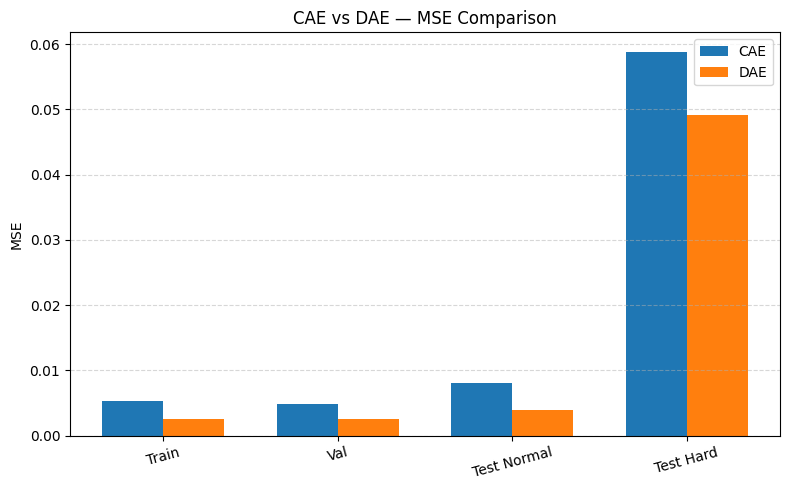

In [27]:
# -------- MSE comparison bar chart --------

x = np.arange(len(splits))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, mse_cae_arr, width, label="CAE")
plt.bar(x + width/2, mse_dae_arr, width, label="DAE")

plt.ylabel("MSE")
plt.title("CAE vs DAE — MSE Comparison")
plt.xticks(x, splits, rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


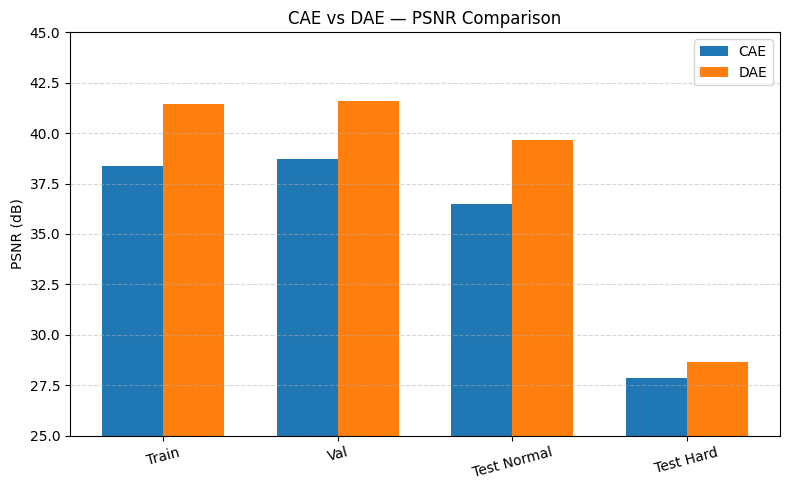

In [28]:
# -------- PSNR comparison bar chart --------

x = np.arange(len(splits))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, psnr_cae_arr, width, label="CAE")
plt.bar(x + width/2, psnr_dae_arr, width, label="DAE")

plt.ylabel("PSNR (dB)")
plt.title("CAE vs DAE — PSNR Comparison")
plt.xticks(x, splits, rotation=15)
plt.ylim(25, 45)  # adjust if you want
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


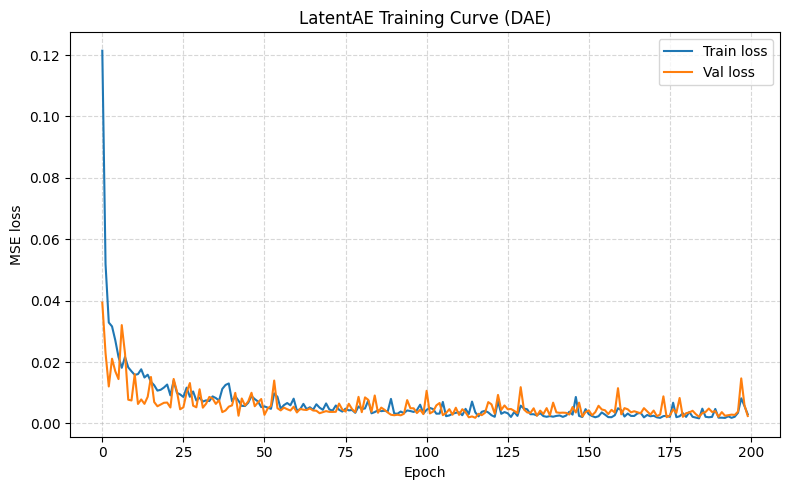

In [29]:
# Only run this if ae_train_history and ae_val_history already exist

plt.figure(figsize=(8, 5))
plt.plot(ae_train_history, label="Train loss")
plt.plot(ae_val_history,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("LatentAE Training Curve (DAE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


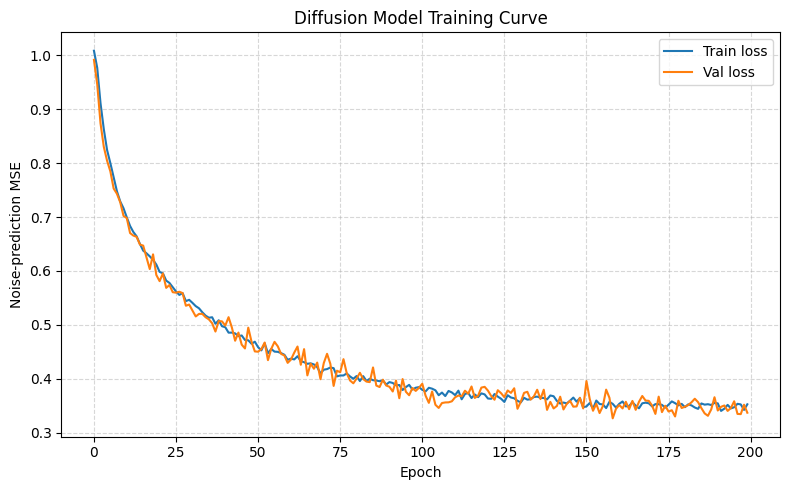

In [30]:
# Only if you stored these during diffusion training
plt.figure(figsize=(8, 5))
plt.plot(diff_train_history, label="Train loss")
plt.plot(diff_val_history,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Noise-prediction MSE")
plt.title("Diffusion Model Training Curve")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
